# Data Loading, Storage and File Formats
## Lab 1 — Sales Data

### Aim
To load sales data from CSV, Excel and JSON files, clean the data, analyze it and create simple visualizations.

**Dataset:** `sklearn.datasets.load_wine()`

The sklearn Wine dataset is used to create a small sales-style dataset for this lab.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


## 1. Create the sales dataset using sklearn

In [2]:
wine = load_wine(as_frame=True)
wine_df = wine.frame

np.random.seed(42)

df = pd.DataFrame({
    "Product": wine_df["target"].map({
        0: "Product A",
        1: "Product B",
        2: "Product C"
    }),
    "Region": np.random.choice(["North", "South", "East", "West"], len(wine_df)),
    "Quantity": np.random.randint(1, 10, len(wine_df)),
    "Unit_Price": np.random.randint(100, 1000, len(wine_df))
})

df["Total_Sales"] = df["Quantity"] * df["Unit_Price"]

# Save the same data in three formats
df.to_csv("sales.csv", index=False)
df.to_excel("sales.xlsx", index=False)
df.to_json("sales.json", orient="records")

print("Files created successfully.")
display(df.head())


Files created successfully.


,Product,Region,Quantity,Unit_Price,Total_Sales
0,Product A,East,1,991,991
1,Product A,West,3,844,2532
2,Product A,North,5,136,680
3,Product A,East,3,379,1137
4,Product A,East,1,448,448


## 2. Load CSV, Excel and JSON files

In [3]:
csv_data = pd.read_csv("sales.csv")
excel_data = pd.read_excel("sales.xlsx")
json_data = pd.read_json("sales.json")

print("CSV:")
display(csv_data.head())

print("Excel:")
display(excel_data.head())

print("JSON:")
display(json_data.head())


CSV:


,Product,Region,Quantity,Unit_Price,Total_Sales
0,Product A,East,1,991,991
1,Product A,West,3,844,2532
2,Product A,North,5,136,680
3,Product A,East,3,379,1137
4,Product A,East,1,448,448


Excel:


,Product,Region,Quantity,Unit_Price,Total_Sales
0,Product A,East,1,991,991
1,Product A,West,3,844,2532
2,Product A,North,5,136,680
3,Product A,East,3,379,1137
4,Product A,East,1,448,448


JSON:


,Product,Region,Quantity,Unit_Price,Total_Sales
0,Product A,East,1,991,991
1,Product A,West,3,844,2532
2,Product A,North,5,136,680
3,Product A,East,3,379,1137
4,Product A,East,1,448,448


## 3. Explore the data

In [4]:
print("Shape:", csv_data.shape)

print("\nColumn names:")
print(csv_data.columns.tolist())

print("\nData types:")
print(csv_data.dtypes)

print("\nMissing values:")
print(csv_data.isnull().sum())

print("\nDuplicate rows:", csv_data.duplicated().sum())


Shape: (178, 5)

Column names:
['Product', 'Region', 'Quantity', 'Unit_Price', 'Total_Sales']

Data types:
Product          str
Region           str
Quantity       int64
Unit_Price     int64
Total_Sales    int64
dtype: object

Missing values:
Product        0
Region         0
Quantity       0
Unit_Price     0
Total_Sales    0
dtype: int64

Duplicate rows: 0


## 4. Clean the data

In [5]:
# Remove duplicate rows
df = csv_data.drop_duplicates()

# Fill missing values
df["Region"] = df["Region"].fillna("Unknown")
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].mean())

# Recalculate total sales
df["Total_Sales"] = df["Quantity"] * df["Unit_Price"]

print("Data cleaned successfully.")
display(df.head())


Data cleaned successfully.


,Product,Region,Quantity,Unit_Price,Total_Sales
0,Product A,East,1,991,991
1,Product A,West,3,844,2532
2,Product A,North,5,136,680
3,Product A,East,3,379,1137
4,Product A,East,1,448,448


## 5. Analyze the sales data

In [6]:
print("Total Sales:", df["Total_Sales"].sum())
print("Average Sales:", df["Total_Sales"].mean())

print("\nSales by Region:")
sales_region = df.groupby("Region")["Total_Sales"].sum()
display(sales_region)

print("\nSales by Product:")
sales_product = df.groupby("Product")["Total_Sales"].sum()
display(sales_product)


Total Sales: 480637
Average Sales: 2700.2078651685392

Sales by Region:


Region
East      93310
North    121057
South    130506
West     135764
Name: Total_Sales, dtype: int64


Sales by Product:


Product
Product A    166509
Product B    200847
Product C    113281
Name: Total_Sales, dtype: int64

## 6. Bar chart — Sales by Region

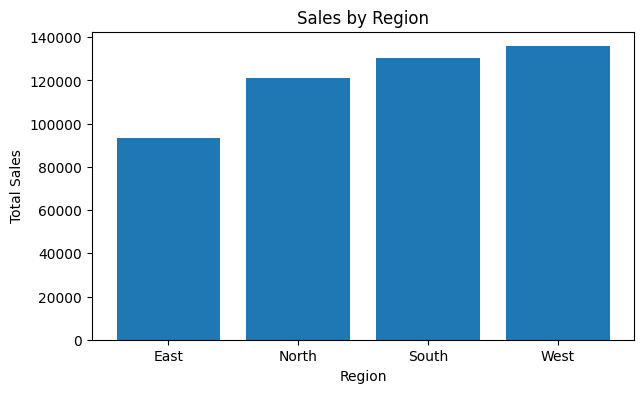

In [7]:
plt.figure(figsize=(7, 4))

plt.bar(sales_region.index, sales_region.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


## 7. Pie chart — Sales by Product

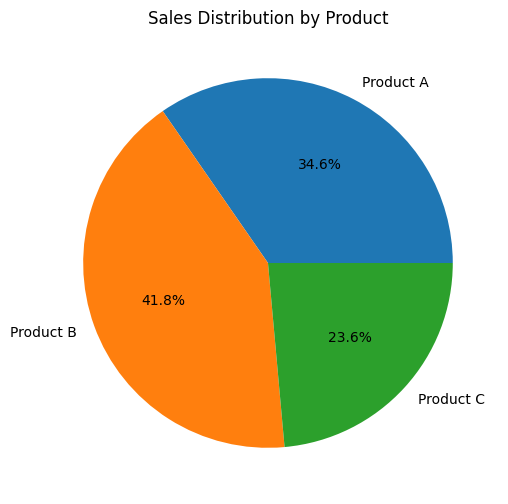

In [8]:
plt.figure(figsize=(6, 6))

plt.pie(
    sales_product.values,
    labels=sales_product.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Product")
plt.show()


## 8. Box plot — Total Sales

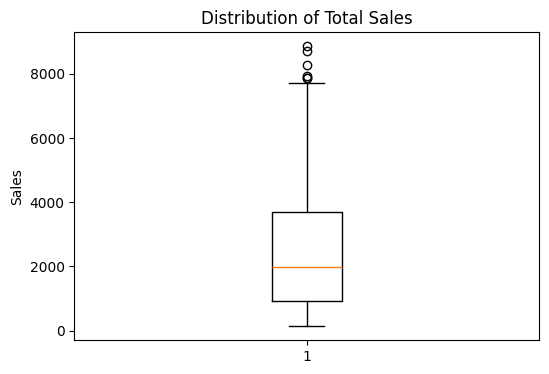

In [9]:
plt.figure(figsize=(6, 4))

plt.boxplot(df["Total_Sales"])

plt.title("Distribution of Total Sales")
plt.ylabel("Sales")
plt.show()


## 9. Save the cleaned data

In [10]:
df.to_csv("Cleaned_Sales_Data.csv", index=False)

print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


## Conclusion

- Sales data was loaded from CSV, Excel and JSON.
- The data was explored and cleaned.
- Total and average sales were calculated.
- Sales were grouped by region and product.
- Bar, pie and box plots were created.
- The cleaned dataset was exported.
